Use Deep Learning LSTM to model ICU patterns.

In [1]:
# LSTM baseline with leakage-safe preprocessing and fair comparison
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Load the dataset
df = pd.read_csv("../data/processed/icu_features.csv")
df.head()

,subject_id,hadm_id,stay_id,heart_rate_x,sbp_x,dbp_x,mbp_x,resp_rate_x,spo2_x,temperature_x,...,sbp,dbp,mbp,resp_rate,spo2,temperature,age,gender,los,mortality
0,10000032,29079034,39553978,96.500000,88.900000,54.100000,62.300000,20.700000,96.300000,98.966670,...,88.900000,54.100000,62.300000,20.700000,96.300000,98.966670,52,0,0.410266,0
1,10000690,25860671,37081114,84.072914,122.893616,60.361702,74.936170,22.557896,95.702126,97.736360,...,122.893616,60.361702,74.936170,22.557896,95.702126,97.736360,86,0,3.893252,0
2,10000980,26913865,39765666,73.636360,142.454540,83.272730,97.545456,20.545454,98.909090,98.133330,...,142.454540,83.272730,97.545456,20.545454,98.909090,98.133330,73,0,0.497535,0
3,10001217,24597018,37067082,93.296295,136.296300,81.333336,93.500000,21.259260,96.074070,99.066666,...,136.296300,81.333336,93.500000,21.259260,96.074070,99.066666,55,0,1.118032,0
4,10001217,27703517,34592300,79.600000,115.869570,73.478264,83.217390,16.640000,93.880000,98.133330,...,115.869570,73.478264,83.217390,16.640000,93.880000,98.133330,55,0,0.948113,0


In [21]:
# Feature configuration for sequence model and tabular baselines
static_features = ["age", "gender", "los"]
vital_features = ["heart_rate", "sbp", "dbp", "mbp", "resp_rate", "spo2", "temperature"]

# Tabular view kept for baseline models and split logic
features = static_features + vital_features
X = df[features].copy()
y = df["mortality"].astype(int)

# Sequence uses three snapshots per vital sign: _x (earlier), _y (middle), and current
seq_suffixes = ["_x", "_y", ""]
seq_feature_names = vital_features + static_features

def build_sequence_frames(frame):
    step_frames = []
    for suffix in seq_suffixes:
        vital_cols = [f"{v}{suffix}" if suffix else v for v in vital_features]
        cols = vital_cols + static_features
        step_frames.append(frame[cols].copy())
    return step_frames

In [22]:
# Train/validation/test split with patient grouping when subject_id is available
from sklearn.model_selection import GroupShuffleSplit

if "subject_id" in df.columns:
    groups = df.loc[X.index, "subject_id"]

    gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_val_idx, test_idx = next(gss_test.split(X, y, groups=groups))

    X_train_val_df = X.iloc[train_val_idx].copy()
    y_train_val = y.iloc[train_val_idx].copy()
    X_test_df = X.iloc[test_idx].copy()
    y_test = y.iloc[test_idx].copy()

    groups_train_val = groups.iloc[train_val_idx]
    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx_rel, val_idx_rel = next(
        gss_val.split(X_train_val_df, y_train_val, groups=groups_train_val)
    )

    X_train_df = X_train_val_df.iloc[train_idx_rel].copy()
    X_val_df = X_train_val_df.iloc[val_idx_rel].copy()
    y_train = y_train_val.iloc[train_idx_rel].copy()
    y_val = y_train_val.iloc[val_idx_rel].copy()

    split_mode = "grouped_by_subject_id"
else:
    X_train_df, X_test_df, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    X_train_df, X_val_df, y_train, y_val = train_test_split(
        X_train_df, y_train, test_size=0.2, random_state=SEED, stratify=y_train
    )
    split_mode = "stratified_random"

print(f"Split mode: {split_mode}")
print(f"Train: {len(X_train_df)}, Val: {len(X_val_df)}, Test: {len(X_test_df)}")
print(
    f"Mortality rate -> train: {y_train.mean():.3f}, "+
    f"val: {y_val.mean():.3f}, test: {y_test.mean():.3f}"
)

Split mode: grouped_by_subject_id
Train: 1370, Val: 315, Test: 419
Mortality rate -> train: 0.125, val: 0.133, test: 0.138


In [24]:
# Fit preprocessing only on training split (prevents leakage)

# Tabular preprocessing for Logistic Regression baseline and CV utilities
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
X_train_imp = imputer.fit_transform(X_train_df)
X_val_imp = imputer.transform(X_val_df)
X_test_imp = imputer.transform(X_test_df)
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

# Sequence preprocessing for LSTM with seq_len=3
train_seq_df = df.loc[X_train_df.index].copy()
val_seq_df = df.loc[X_val_df.index].copy()
test_seq_df = df.loc[X_test_df.index].copy()

train_steps = build_sequence_frames(train_seq_df)
val_steps = build_sequence_frames(val_seq_df)
test_steps = build_sequence_frames(test_seq_df)

def stack_steps(step_frames):
    return np.stack([step.values for step in step_frames], axis=1)

X_train_seq_raw = stack_steps(train_steps)
X_val_seq_raw = stack_steps(val_steps)
X_test_seq_raw = stack_steps(test_steps)

seq_imputer = SimpleImputer(strategy="median")
seq_scaler = StandardScaler()

X_train_seq_2d = X_train_seq_raw.reshape(-1, X_train_seq_raw.shape[-1])
X_val_seq_2d = X_val_seq_raw.reshape(-1, X_val_seq_raw.shape[-1])
X_test_seq_2d = X_test_seq_raw.reshape(-1, X_test_seq_raw.shape[-1])

X_train_seq_imp = seq_imputer.fit_transform(X_train_seq_2d)
X_val_seq_imp = seq_imputer.transform(X_val_seq_2d)
X_test_seq_imp = seq_imputer.transform(X_test_seq_2d)

X_train_seq_scaled = seq_scaler.fit_transform(X_train_seq_imp).reshape(X_train_seq_raw.shape)
X_val_seq_scaled = seq_scaler.transform(X_val_seq_imp).reshape(X_val_seq_raw.shape)
X_test_seq_scaled = seq_scaler.transform(X_test_seq_imp).reshape(X_test_seq_raw.shape)

# Convert sequence arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_seq_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_seq_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_seq_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [25]:
# Sequence sanity check for LSTM input: (batch, seq_len=3, features)
print("LSTM tensor shape:", tuple(X_train_tensor.shape))

LSTM tensor shape: (1370, 3, 10)


In [26]:
# Model definition (output logits; no sigmoid here)
class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out

In [27]:
# Initialize model, weighted loss, and optimizer
input_size = X_train_tensor.shape[2]
model = LSTMModel(input_size)

pos_count = float(y_train_tensor.sum().item())
neg_count = float(len(y_train_tensor) - pos_count)
pos_weight = torch.tensor([neg_count / max(pos_count, 1.0)], dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [28]:
# Mini-batch training with validation-based early stopping
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

epochs = 40
patience = 6
best_val_loss = float("inf")
patience_counter = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        logits = model(X_batch).squeeze(1)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            logits = model(X_batch).squeeze(1)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch + 1:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "../models/lstm_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

Epoch 01 | train_loss=1.2020 | val_loss=1.2144
Epoch 02 | train_loss=1.1282 | val_loss=1.0666
Epoch 03 | train_loss=0.9597 | val_loss=0.9565
Epoch 04 | train_loss=0.8951 | val_loss=0.9301
Epoch 05 | train_loss=0.8774 | val_loss=0.9184
Epoch 06 | train_loss=0.8660 | val_loss=0.9155
Epoch 07 | train_loss=0.8539 | val_loss=0.9051
Epoch 08 | train_loss=0.8525 | val_loss=0.9047
Epoch 09 | train_loss=0.8418 | val_loss=0.8973
Epoch 10 | train_loss=0.8350 | val_loss=0.8993
Epoch 11 | train_loss=0.8298 | val_loss=0.8948
Epoch 12 | train_loss=0.8241 | val_loss=0.8966
Epoch 13 | train_loss=0.8215 | val_loss=0.8932
Epoch 14 | train_loss=0.8317 | val_loss=0.8883
Epoch 15 | train_loss=0.8203 | val_loss=0.9027
Epoch 16 | train_loss=0.8088 | val_loss=0.9002
Epoch 17 | train_loss=0.8081 | val_loss=0.8929
Epoch 18 | train_loss=0.8037 | val_loss=0.9104
Epoch 19 | train_loss=0.8023 | val_loss=0.8926
Epoch 20 | train_loss=0.7983 | val_loss=0.9122
Early stopping at epoch 20


In [29]:
# Evaluate best LSTM model and compare against Logistic Regression baseline
model.load_state_dict(torch.load("../models/lstm_model.pt", map_location="cpu"))
model.eval()

with torch.no_grad():
    val_logits = model(X_val_tensor).squeeze(1)
    test_logits = model(X_test_tensor).squeeze(1)

val_probs = torch.sigmoid(val_logits).numpy()
test_probs = torch.sigmoid(test_logits).numpy()

y_val_np = y_val.values
y_test_np = y_test.values

# Choose decision threshold by maximizing validation F1
thresholds = np.linspace(0.10, 0.90, 17)

def best_f1_threshold(y_true, probs, threshold_grid):
    return max(
        threshold_grid,
        key=lambda t: f1_score(y_true, (probs >= t).astype(int), zero_division=0),
    )

best_threshold = best_f1_threshold(y_val_np, val_probs, thresholds)
lstm_pred = (test_probs >= best_threshold).astype(int)
lstm_auc = roc_auc_score(y_test_np, test_probs)
lstm_pr_auc = average_precision_score(y_test_np, test_probs)
lstm_f1 = f1_score(y_test_np, lstm_pred, zero_division=0)

print(f"LSTM threshold={best_threshold:.2f}")
print(f"LSTM test ROC-AUC: {lstm_auc:.4f}")
print(f"LSTM test PR-AUC: {lstm_pr_auc:.4f}")
print(f"LSTM test F1: {lstm_f1:.4f}")
print(classification_report(y_test_np, lstm_pred, digits=4, zero_division=0))

# Fair baseline on identical train/val/test preprocessing with threshold tuning on validation
lr = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
lr.fit(X_train_scaled, y_train.values)
lr_val_probs = lr.predict_proba(X_val_scaled)[:, 1]
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_threshold = best_f1_threshold(y_val_np, lr_val_probs, thresholds)
lr_pred = (lr_probs >= lr_threshold).astype(int)

lr_auc = roc_auc_score(y_test_np, lr_probs)
lr_pr_auc = average_precision_score(y_test_np, lr_probs)
lr_f1 = f1_score(y_test_np, lr_pred, zero_division=0)

print("\nLogistic Regression baseline")
print(f"LR threshold={lr_threshold:.2f}")
print(f"LR test ROC-AUC: {lr_auc:.4f}")
print(f"LR test PR-AUC: {lr_pr_auc:.4f}")
print(f"LR test F1: {lr_f1:.4f}")

LSTM threshold=0.75
LSTM test ROC-AUC: 0.7952
LSTM test PR-AUC: 0.4479
LSTM test F1: 0.3810
              precision    recall  f1-score   support

           0     0.8978    0.9252    0.9113       361
           1     0.4255    0.3448    0.3810        58

    accuracy                         0.8449       419
   macro avg     0.6617    0.6350    0.6461       419
weighted avg     0.8325    0.8449    0.8379       419


Logistic Regression baseline
LR threshold=0.60
LR test ROC-AUC: 0.7780
LR test PR-AUC: 0.4180
LR test F1: 0.4478


In [31]:
# Quick metric table
metrics_df = pd.DataFrame(
    [
        {"model": "LSTM", "roc_auc": lstm_auc, "pr_auc": lstm_pr_auc, "f1": lstm_f1},
        {"model": "LogisticRegression", "roc_auc": lr_auc, "pr_auc": lr_pr_auc, "f1": lr_f1},
    ]
).sort_values("roc_auc", ascending=False)

metrics_df

,model,roc_auc,pr_auc,f1
0,LSTM,0.795157,0.447867,0.380952
1,LogisticRegression,0.778011,0.417963,0.447761


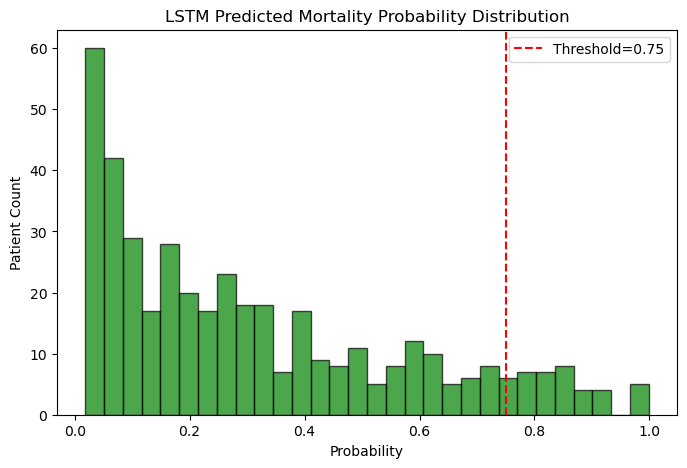

In [11]:
# Visualization: LSTM predicted probability distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(test_probs, bins=30, color="green", edgecolor="black", alpha=0.7)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Threshold={best_threshold:.2f}")
plt.title("LSTM Predicted Mortality Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Patient Count")
plt.legend()
plt.show()

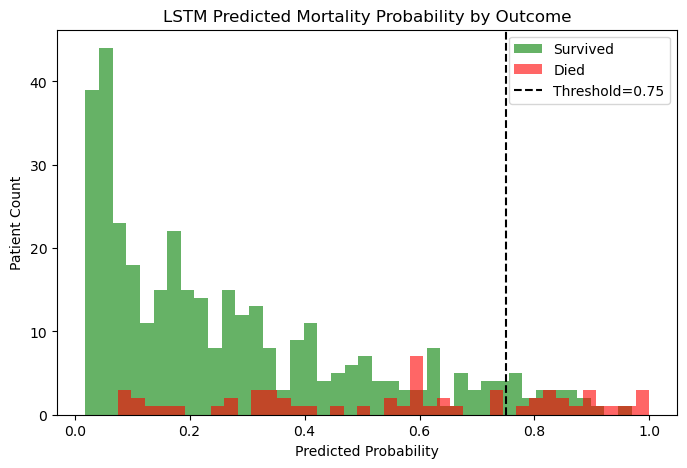

In [12]:
# Compare LSTM probability distributions by true outcome
import matplotlib.pyplot as plt

survived = test_probs[y_test_np == 0]
died = test_probs[y_test_np == 1]

plt.figure(figsize=(8, 5))
plt.hist(survived, bins=40, color="green", alpha=0.6, label="Survived")
plt.hist(died, bins=40, color="red", alpha=0.6, label="Died")
plt.axvline(best_threshold, color="black", linestyle="--", label=f"Threshold={best_threshold:.2f}")
plt.title("LSTM Predicted Mortality Probability by Outcome")
plt.xlabel("Predicted Probability")
plt.ylabel("Patient Count")
plt.legend()
plt.show()

In [13]:
# 1) Patient-level leakage check across splits
if "subject_id" in df.columns:
    train_subjects = set(df.loc[X_train_df.index, "subject_id"])
    val_subjects = set(df.loc[X_val_df.index, "subject_id"])
    test_subjects = set(df.loc[X_test_df.index, "subject_id"])

    overlap_train_test = train_subjects.intersection(test_subjects)
    overlap_train_val = train_subjects.intersection(val_subjects)
    overlap_val_test = val_subjects.intersection(test_subjects)

    print(f"Unique subjects - train: {len(train_subjects)}, val: {len(val_subjects)}, test: {len(test_subjects)}")
    print(f"Overlap train-test: {len(overlap_train_test)}")
    print(f"Overlap train-val: {len(overlap_train_val)}")
    print(f"Overlap val-test: {len(overlap_val_test)}")

    if len(overlap_train_test) > 0 or len(overlap_train_val) > 0 or len(overlap_val_test) > 0:
        print("WARNING: Same patient appears in multiple splits. Use GroupShuffleSplit/GroupKFold on subject_id.")
    else:
        print("OK: No patient overlap detected across train/val/test splits.")
else:
    print("subject_id not found; cannot run patient-level leakage check.")

Unique subjects - train: 962, val: 241, test: 301
Overlap train-test: 0
Overlap train-val: 0
Overlap val-test: 0
OK: No patient overlap detected across train/val/test splits.


In [30]:
# 2) Tree-model benchmark (HistGradientBoosting)
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    random_state=SEED,
    max_depth=6,
    learning_rate=0.05,
    max_iter=300,
    l2_regularization=1.0,
    class_weight="balanced",
)
hgb.fit(X_train_imp, y_train.values)

hgb_val_probs = hgb.predict_proba(X_val_imp)[:, 1]
hgb_probs = hgb.predict_proba(X_test_imp)[:, 1]
hgb_threshold = best_f1_threshold(y_val_np, hgb_val_probs, thresholds)
hgb_pred = (hgb_probs >= hgb_threshold).astype(int)

hgb_auc = roc_auc_score(y_test_np, hgb_probs)
hgb_pr_auc = average_precision_score(y_test_np, hgb_probs)
hgb_f1 = f1_score(y_test_np, hgb_pred, zero_division=0)

print("HistGradientBoosting baseline")
print(f"HGB threshold={hgb_threshold:.2f}")
print(f"HGB test ROC-AUC: {hgb_auc:.4f}")
print(f"HGB test PR-AUC: {hgb_pr_auc:.4f}")
print(f"HGB test F1: {hgb_f1:.4f}")

HistGradientBoosting baseline
HGB threshold=0.40
HGB test ROC-AUC: 0.7684
HGB test PR-AUC: 0.4541
HGB test F1: 0.4068


In [32]:
# 3) Bootstrapped confidence intervals for ROC-AUC and PR-AUC
def bootstrap_metric_ci(y_true, y_prob, metric_fn, n_boot=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    scores = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        y_b = y_true[idx]
        p_b = y_prob[idx]
        if len(np.unique(y_b)) < 2:
            continue
        scores.append(metric_fn(y_b, p_b))

    if len(scores) == 0:
        return np.nan, np.nan, np.nan

    scores = np.array(scores)
    return float(scores.mean()), float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))

summary_rows = []
for model_name, probs, f1_val in [
    ("LSTM", test_probs, lstm_f1),
    ("LogisticRegression", lr_probs, lr_f1),
    ("HistGradientBoosting", hgb_probs, hgb_f1),
]:
    roc_mean, roc_lo, roc_hi = bootstrap_metric_ci(y_test_np, probs, roc_auc_score)
    pr_mean, pr_lo, pr_hi = bootstrap_metric_ci(y_test_np, probs, average_precision_score)
    summary_rows.append(
        {
            "model": model_name,
            "roc_auc": roc_auc_score(y_test_np, probs),
            "roc_auc_ci95": f"[{roc_lo:.3f}, {roc_hi:.3f}]",
            "pr_auc": average_precision_score(y_test_np, probs),
            "pr_auc_ci95": f"[{pr_lo:.3f}, {pr_hi:.3f}]",
            "f1": f1_val,
        }
    )

robust_metrics_df = pd.DataFrame(summary_rows).sort_values("roc_auc", ascending=False)
robust_metrics_df

,model,roc_auc,roc_auc_ci95,pr_auc,pr_auc_ci95,f1
0,LSTM,0.795157,"[0.736, 0.851]",0.447867,"[0.326, 0.573]",0.380952
1,LogisticRegression,0.778011,"[0.714, 0.840]",0.417963,"[0.294, 0.556]",0.447761
2,HistGradientBoosting,0.768364,"[0.702, 0.833]",0.454070,"[0.336, 0.585]",0.406780


In [33]:
# 4) Grouped cross-validation summary for tabular baselines
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold

if "subject_id" in df.columns:
    cv_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_groups = df.loc[X.index, "subject_id"].values
    split_iterator = cv_splitter.split(X, y, groups=cv_groups)
    cv_mode = "StratifiedGroupKFold"
else:
    cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    split_iterator = cv_splitter.split(X, y)
    cv_mode = "StratifiedKFold"

cv_rows = []
for fold, (tr_idx, te_idx) in enumerate(split_iterator, start=1):
    X_tr_df = X.iloc[tr_idx].copy()
    X_te_df = X.iloc[te_idx].copy()
    y_tr = y.iloc[tr_idx].values
    y_te = y.iloc[te_idx].values

    fold_imputer = SimpleImputer(strategy="median")
    fold_scaler = StandardScaler()

    X_tr_imp = fold_imputer.fit_transform(X_tr_df)
    X_te_imp = fold_imputer.transform(X_te_df)
    X_tr_scaled = fold_scaler.fit_transform(X_tr_imp)
    X_te_scaled = fold_scaler.transform(X_te_imp)

    lr_cv = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
    lr_cv.fit(X_tr_scaled, y_tr)
    lr_cv_probs = lr_cv.predict_proba(X_te_scaled)[:, 1]
    cv_rows.append(
        {
            "fold": fold,
            "model": "LogisticRegression",
            "roc_auc": roc_auc_score(y_te, lr_cv_probs),
            "pr_auc": average_precision_score(y_te, lr_cv_probs),
        }
    )

    hgb_cv = HistGradientBoostingClassifier(
        random_state=SEED,
        max_depth=6,
        learning_rate=0.05,
        max_iter=300,
        l2_regularization=1.0,
        class_weight="balanced",
    )
    hgb_cv.fit(X_tr_imp, y_tr)
    hgb_cv_probs = hgb_cv.predict_proba(X_te_imp)[:, 1]
    cv_rows.append(
        {
            "fold": fold,
            "model": "HistGradientBoosting",
            "roc_auc": roc_auc_score(y_te, hgb_cv_probs),
            "pr_auc": average_precision_score(y_te, hgb_cv_probs),
        }
    )

cv_fold_metrics_df = pd.DataFrame(cv_rows)
cv_summary_df = (
    cv_fold_metrics_df.groupby("model", as_index=False)
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
    )
    .sort_values("roc_auc_mean", ascending=False)
    .reset_index(drop=True)
)

print(f"CV mode: {cv_mode}")
cv_summary_df

CV mode: StratifiedGroupKFold


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,HistGradientBoosting,0.797916,0.043685,0.442881,0.063175
1,LogisticRegression,0.795129,0.041801,0.409623,0.058450


In [34]:
# 5) Persist holdout and CV metrics artifacts
from pathlib import Path
import json

results_dir = Path("../results/metrics")
results_dir.mkdir(parents=True, exist_ok=True)

thresholds_df = pd.DataFrame(
    [
        {"model": "LSTM", "threshold": float(best_threshold)},
        {"model": "LogisticRegression", "threshold": float(lr_threshold)},
        {"model": "HistGradientBoosting", "threshold": float(hgb_threshold)},
    ]
)

robust_metrics_out = robust_metrics_df.merge(thresholds_df, on="model", how="left")

holdout_path = results_dir / "holdout_model_comparison_lstm_notebook.csv"
cv_fold_path = results_dir / "cv_fold_metrics_lstm_notebook.csv"
cv_summary_path = results_dir / "cv_model_comparison_lstm_notebook.csv"
summary_json_path = results_dir / "lstm_notebook_run_summary.json"

robust_metrics_out.to_csv(holdout_path, index=False)
cv_fold_metrics_df.to_csv(cv_fold_path, index=False)
cv_summary_df.to_csv(cv_summary_path, index=False)

run_summary = {
    "seed": int(SEED),
    "split_mode": split_mode,
    "n_train": int(len(X_train_df)),
    "n_val": int(len(X_val_df)),
    "n_test": int(len(X_test_df)),
    "thresholds": {
        "LSTM": float(best_threshold),
        "LogisticRegression": float(lr_threshold),
        "HistGradientBoosting": float(hgb_threshold),
    },
    "holdout_metrics": robust_metrics_out.to_dict(orient="records"),
    "cv_summary": cv_summary_df.to_dict(orient="records"),
}

with summary_json_path.open("w", encoding="utf-8") as f:
    json.dump(run_summary, f, indent=2)

print("Saved metrics artifacts:")
print(f"- {holdout_path}")
print(f"- {cv_fold_path}")
print(f"- {cv_summary_path}")
print(f"- {summary_json_path}")

Saved metrics artifacts:
- ../results/metrics/holdout_model_comparison_lstm_notebook.csv
- ../results/metrics/cv_fold_metrics_lstm_notebook.csv
- ../results/metrics/cv_model_comparison_lstm_notebook.csv
- ../results/metrics/lstm_notebook_run_summary.json
